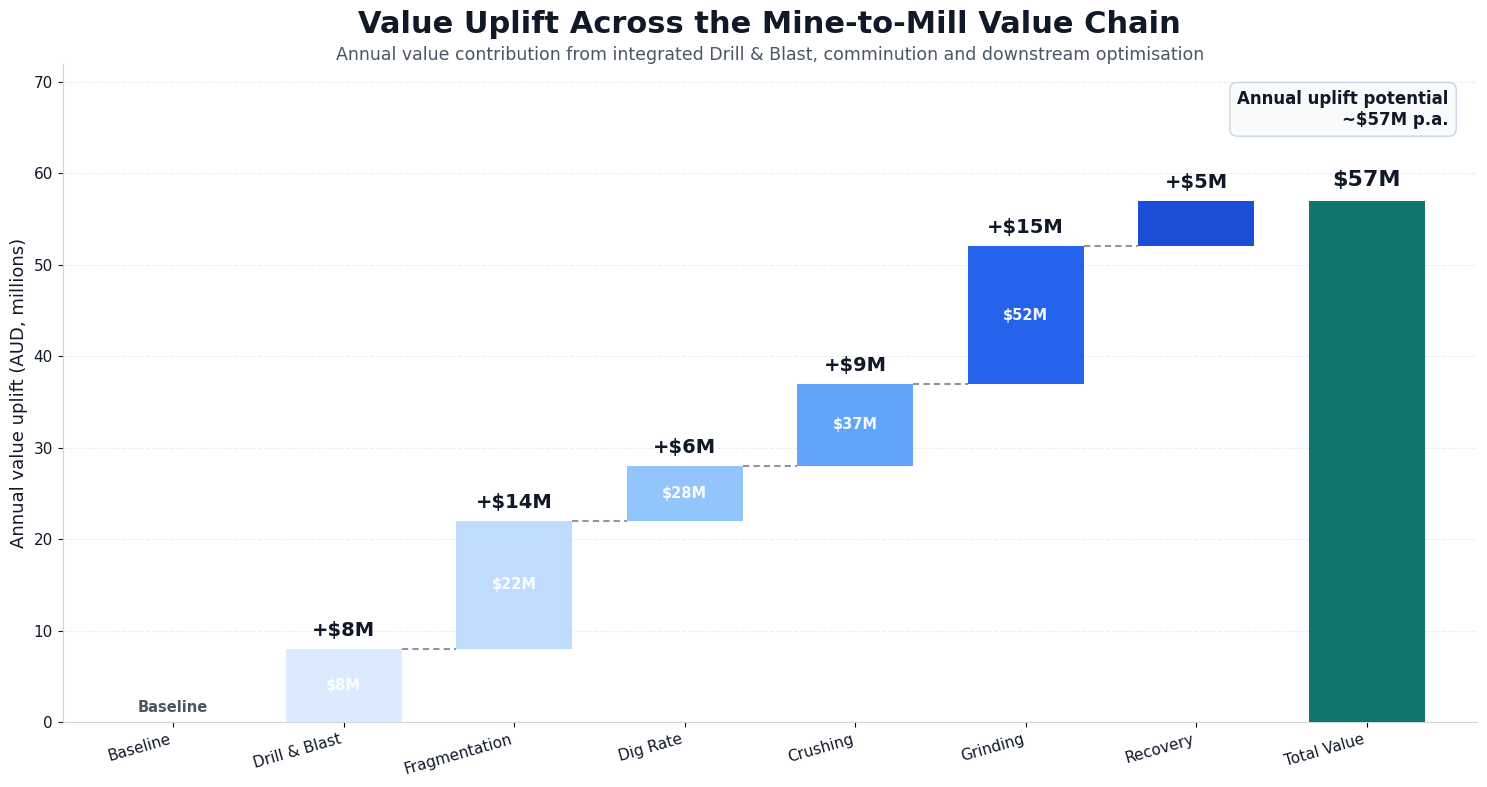

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Annual uplift data
# Large metals mining operation
# AUD millions per annum
# -----------------------------
step_labels = [
    "Drill & Blast",
    "Fragmentation",
    "Dig Rate",
    "Crushing",
    "Grinding",
    "Recovery",
]
increments = np.array([8, 14, 6, 9, 15, 5], dtype=float)

cum = np.cumsum(increments)
starts = np.r_[0, cum[:-1]]
total_value = cum[-1]

labels = ["Baseline"] + step_labels + ["Total Value"]
x = np.arange(len(labels))

heights = np.r_[0, increments, total_value]
bottoms = np.r_[0, starts, 0]

# -----------------------------
# Styling
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

baseline_colour = "#D1D5DB"
step_colours = [
    "#DBEAFE",  # Drill & Blast
    "#BFDBFE",  # Fragmentation
    "#93C5FD",  # Dig Rate
    "#60A5FA",  # Crushing
    "#2563EB",  # Grinding
    "#1D4ED8",  # Recovery
]
total_colour = "#0F766E"

connector_colour = "#6B7280"
text_dark = "#111827"
text_mid = "#4B5563"
grid_colour = "#E5E7EB"

colours = [baseline_colour] + step_colours + [total_colour]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(15, 8), facecolor="white")
ax.set_facecolor("white")

bars = ax.bar(
    x,
    heights,
    bottom=bottoms,
    width=0.68,
    color=colours,
    edgecolor="none",
    zorder=3,
)

# Connector lines
for i in range(1, len(labels) - 2):
    y = bottoms[i] + heights[i]
    ax.plot(
        [x[i] + 0.34, x[i + 1] - 0.34],
        [y, y],
        color=connector_colour,
        linewidth=1.5,
        linestyle=(0, (3, 2)),
        alpha=0.75,
        zorder=2,
    )

# -----------------------------
# Labels
# -----------------------------
# Baseline label
ax.text(
    x[0],
    0.8,
    "Baseline",
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=text_mid,
    fontweight="bold",
)

# Increment labels above bars
for i in range(1, len(labels) - 1):
    ax.text(
        x[i],
        bottoms[i] + heights[i] + 1.0,
        f"+${heights[i]:.0f}M",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        color=text_dark,
    )

# Cumulative labels inside bars
for i in range(1, len(labels) - 2):
    ax.text(
        x[i],
        bottoms[i] + heights[i] / 2,
        f"${bottoms[i] + heights[i]:.0f}M",
        ha="center",
        va="center",
        fontsize=10.5,
        color="white",
        fontweight="bold",
        alpha=0.95,
    )

# Total label
ax.text(
    x[-1],
    heights[-1] + 1.2,
    f"${heights[-1]:.0f}M",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
    color=text_dark,
)

# -----------------------------
# Titles and subtitle
# -----------------------------
ax.set_title(
    "Value Uplift Across the Mine-to-Mill Value Chain",
    pad=22,
    color=text_dark,
)

ax.text(
    0.5,
    1.00,
    "Annual value contribution from integrated Drill & Blast, comminution and downstream optimisation",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12.5,
    color=text_mid,
)

# -----------------------------
# Top-right callout box
# -----------------------------
ax.text(
    0.98, 0.96,
    "Annual uplift potential\n~$57M p.a.",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=12,
    fontweight="bold",
    color=text_dark,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="#F8FAFC",
        edgecolor="#CBD5E1",
        linewidth=1.0,
    ),
)

# -----------------------------
# Axes formatting
# -----------------------------
ax.set_ylabel("Annual value uplift (AUD, millions)", color=text_dark)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=16, ha="right", color=text_dark)

ax.set_ylim(0, 72)
ax.set_yticks(np.arange(0, 71, 10))
ax.tick_params(axis="y", colors=text_dark)

# Minimal spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D1D5DB")
ax.spines["bottom"].set_color("#D1D5DB")

# Light grid
ax.grid(axis="y", color=grid_colour, linestyle="--", linewidth=0.8, alpha=0.7, zorder=1)
ax.grid(axis="x", visible=False)

ax.margins(x=0.04)

plt.tight_layout()
plt.show()

# To save for PowerPoint:
# plt.savefig("mine_to_mill_value_waterfall_with_grinding.png", dpi=300, bbox_inches="tight")